## Importing Required Libraries

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

## Data Ingestion

In [4]:
subscribers_df=pd.read_csv(r"C:\Users\sharath\OneDrive\Desktop\py_project\raw_data\subscribers.csv")
content_con_df=pd.read_csv(r"C:\Users\sharath\OneDrive\Desktop\py_project\raw_data\content_consumption.csv")
content_df=pd.read_csv(r"C:\Users\sharath\OneDrive\Desktop\py_project\raw_data\content.csv")


## 3️⃣ EDA

In [5]:
content_df.head(2)

,Unnamed: 0,content_id,content_type,language,genre,runtime
0,0,CJSMBEACT2e633,Movie,Bengali,Action,90
1,1,CJSMBEACT34aec,Movie,Bengali,Action,135


In [6]:
content_df.shape

(2360, 6)

In [7]:
subscribers_df.shape

(44620, 9)

In [8]:
content_con_df.shape

(133860, 4)

In [9]:
subscribers_df.head(5)

,Unnamed: 0,user_id,age_group,city_tier,subscription_date,subscription_plan,last_active_date,plan_change_date,new_subscription_plan
0,0,UIDJS0000751588f,18-24,Tier 1,2024-06-10,Premium,NaN,NaN,NaN
1,1,UIDJS000093eeb86,18-24,Tier 1,2024-11-09,Free,NaN,NaN,NaN
2,2,UIDJS00010d7fa1e,25-34,Tier 1,2024-08-08,Free,NaN,NaN,NaN
3,3,UIDJS00013411a85,35-44,Tier 2,2024-05-31,VIP,NaN,NaN,NaN
4,4,UIDJS0003a3f54cf,35-44,Tier 1,2024-09-20,Premium,NaN,NaN,NaN


In [10]:
content_con_df.head(3)

,Unnamed: 0,user_id,device_type,total_watch_time_mins
0,0,UIDJS877cc0e02c9,Mobile,14613
1,1,UIDJS06384e7ff06,Mobile,13271
2,2,UIDJSc3997b7beb7,Mobile,4644


In [11]:
content_df['content_type'].unique()

array(['Movie', 'Series', 'Sports'], dtype=object)

In [12]:
subscribers_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44620 entries, 0 to 44619
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Unnamed: 0             44620 non-null  int64 
 1   user_id                44620 non-null  object
 2   age_group              44620 non-null  object
 3   city_tier              44620 non-null  object
 4   subscription_date      44620 non-null  object
 5   subscription_plan      44620 non-null  object
 6   last_active_date       6652 non-null   object
 7   plan_change_date       7090 non-null   object
 8   new_subscription_plan  7090 non-null   object
dtypes: int64(1), object(8)
memory usage: 3.1+ MB


In [13]:
subscribers_df.describe()

,Unnamed: 0
count,44620.000000
mean,22309.500000
std,12880.828842
min,0.000000
25%,11154.750000
50%,22309.500000
75%,33464.250000
max,44619.000000


In [14]:
content_con_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 133860 entries, 0 to 133859
Data columns (total 4 columns):
 #   Column                 Non-Null Count   Dtype 
---  ------                 --------------   ----- 
 0   Unnamed: 0             133860 non-null  int64 
 1   user_id                133860 non-null  object
 2   device_type            133860 non-null  object
 3   total_watch_time_mins  133860 non-null  int64 
dtypes: int64(2), object(2)
memory usage: 4.1+ MB


In [15]:
content_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2360 entries, 0 to 2359
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Unnamed: 0    2360 non-null   int64 
 1   content_id    2360 non-null   object
 2   content_type  2360 non-null   object
 3   language      2360 non-null   object
 4   genre         2360 non-null   object
 5   runtime       2360 non-null   int64 
dtypes: int64(2), object(4)
memory usage: 110.8+ KB


## Data Validation (checking null values etc)

In [16]:
subscribers_df.isnull().sum()

Unnamed: 0                   0
user_id                      0
age_group                    0
city_tier                    0
subscription_date            0
subscription_plan            0
last_active_date         37968
plan_change_date         37530
new_subscription_plan    37530
dtype: int64

In [17]:
content_con_df.isnull().sum()

Unnamed: 0               0
user_id                  0
device_type              0
total_watch_time_mins    0
dtype: int64

In [18]:
content_df.isnull().sum()

Unnamed: 0      0
content_id      0
content_type    0
language        0
genre           0
runtime         0
dtype: int64

##  Data Manipulation

In [19]:
subscribers_df.drop("Unnamed: 0",axis=1,inplace=True)
content_con_df.drop("Unnamed: 0",axis=1,inplace=True)
content_df.drop("Unnamed: 0",axis=1,inplace=True)



##  Data Transformation

In [20]:
subscribers_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44620 entries, 0 to 44619
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   user_id                44620 non-null  object
 1   age_group              44620 non-null  object
 2   city_tier              44620 non-null  object
 3   subscription_date      44620 non-null  object
 4   subscription_plan      44620 non-null  object
 5   last_active_date       6652 non-null   object
 6   plan_change_date       7090 non-null   object
 7   new_subscription_plan  7090 non-null   object
dtypes: object(8)
memory usage: 2.7+ MB


In [21]:
subscribers_df['subscription_date']=pd.to_datetime(subscribers_df['subscription_date'])

In [22]:
subscribers_df['last_active_date']=pd.to_datetime(subscribers_df['last_active_date'])
subscribers_df['plan_change_date']=pd.to_datetime(subscribers_df['plan_change_date'])

In [23]:
subscribers_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44620 entries, 0 to 44619
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   user_id                44620 non-null  object        
 1   age_group              44620 non-null  object        
 2   city_tier              44620 non-null  object        
 3   subscription_date      44620 non-null  datetime64[ns]
 4   subscription_plan      44620 non-null  object        
 5   last_active_date       6652 non-null   datetime64[ns]
 6   plan_change_date       7090 non-null   datetime64[ns]
 7   new_subscription_plan  7090 non-null   object        
dtypes: datetime64[ns](3), object(5)
memory usage: 2.7+ MB


In [24]:
content_df.head()

,content_id,content_type,language,genre,runtime
0,CJSMBEACT2e633,Movie,Bengali,Action,90
1,CJSMBEACT34aec,Movie,Bengali,Action,135
2,CJSMBEACT83b46,Movie,Bengali,Action,120
3,CJSMBECOM12e7a,Movie,Bengali,Comedy,120
4,CJSMBECOM5431a,Movie,Bengali,Comedy,135


In [25]:
content_numerical=content_df.select_dtypes("int")

In [26]:
content_categorial=content_df.select_dtypes("object")

<Axes: >

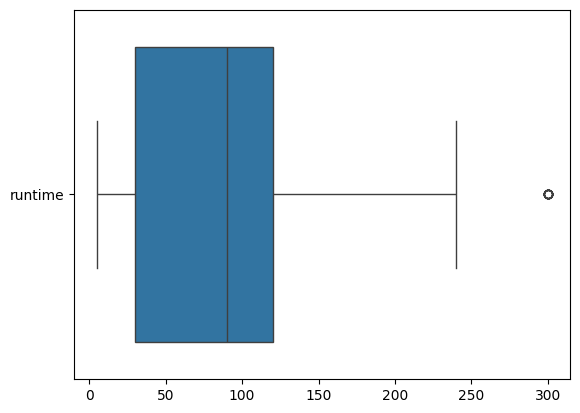

In [27]:
sns.boxplot(data=content_numerical,orient='h')

<Axes: ylabel='Count'>

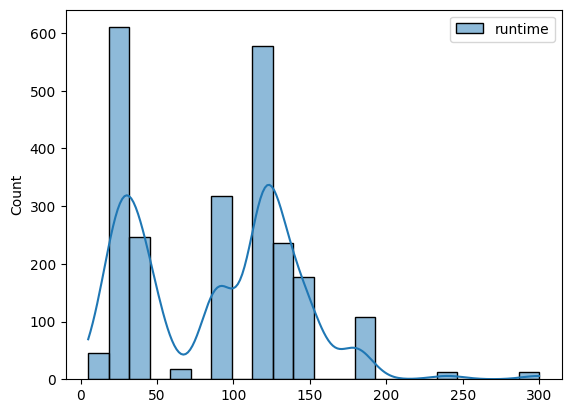

In [28]:
sns.histplot(data=content_numerical,kde=True)

<Axes: xlabel='count', ylabel='content_type'>

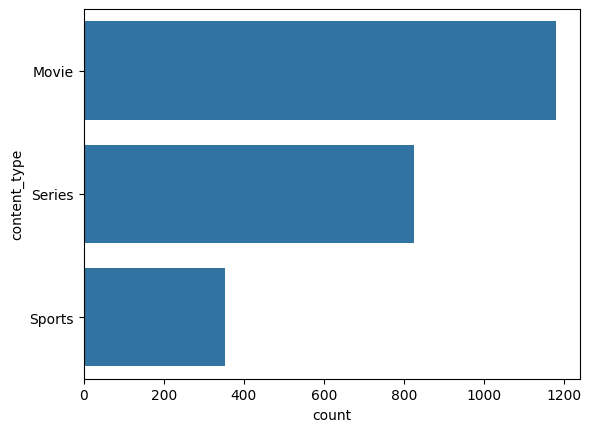

In [29]:
sns.countplot(data=content_categorial['content_type'])

<Axes: xlabel='count', ylabel='language'>

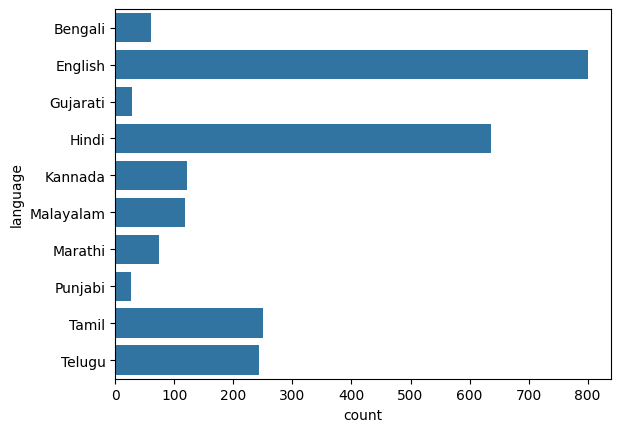

In [30]:
sns.countplot(data=content_categorial['language'])

## bivarient analysis

<Axes: xlabel='count', ylabel='language'>

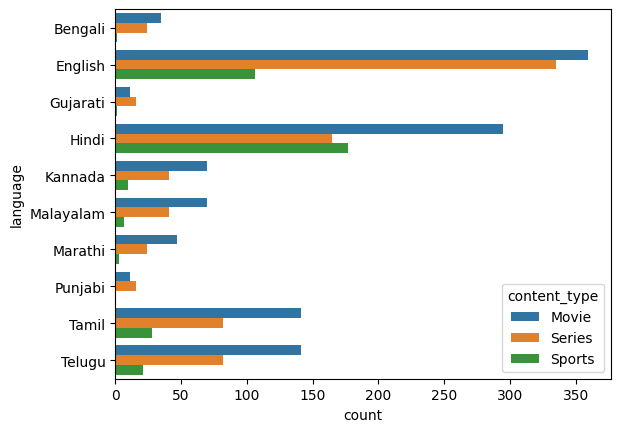

In [31]:
sns.countplot(data=content_categorial,y='language',hue='content_type')

## Device Analysis (Content Consumption – Aggregation)

In [32]:
content_con_df.head(3)

,user_id,device_type,total_watch_time_mins
0,UIDJS877cc0e02c9,Mobile,14613
1,UIDJS06384e7ff06,Mobile,13271
2,UIDJSc3997b7beb7,Mobile,4644


In [33]:
avg_dev_cont_con=content_con_df.groupby('device_type').agg({'total_watch_time_mins':'mean'})

In [34]:
avg_dev_cont_con

,total_watch_time_mins
device_type,
Laptop,4857.260399
Mobile,10563.645316
TV,5682.622277


<Axes: xlabel='device_type', ylabel='total_watch_time_mins'>

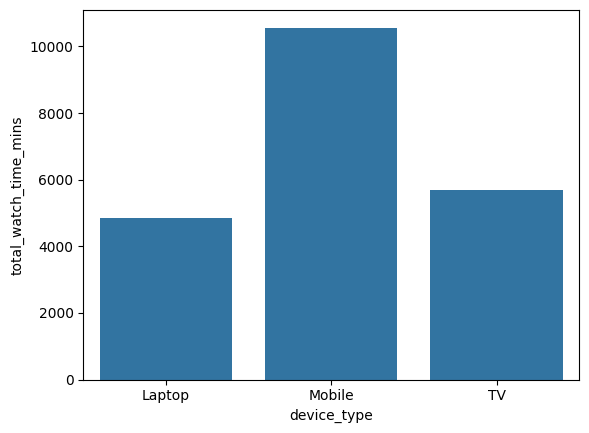

In [35]:
sns.barplot(data=avg_dev_cont_con,x='device_type',y='total_watch_time_mins')

## analysing trends in subscribers accusion and subbscriber demographics 

In [36]:
subscribers_df.head(3)

,user_id,age_group,city_tier,subscription_date,subscription_plan,last_active_date,plan_change_date,new_subscription_plan
0,UIDJS0000751588f,18-24,Tier 1,2024-06-10,Premium,NaT,NaT,NaN
1,UIDJS000093eeb86,18-24,Tier 1,2024-11-09,Free,NaT,NaT,NaN
2,UIDJS00010d7fa1e,25-34,Tier 1,2024-08-08,Free,NaT,NaT,NaN


In [37]:
age_vs_sub_plan=subscribers_df.groupby('age_group').value_counts(['subscription_plan']).to_frame().reset_index()

In [38]:
age_vs_sub_plan

,age_group,subscription_plan,count
0,18-24,VIP,3252
1,18-24,Premium,2305
2,18-24,Free,2119
3,25-34,VIP,8673
4,25-34,Premium,5938
5,25-34,Free,5458
6,35-44,VIP,4846
7,35-44,Premium,3417
8,35-44,Free,3011
9,45+,VIP,2386


<Axes: xlabel='age_group', ylabel='count'>

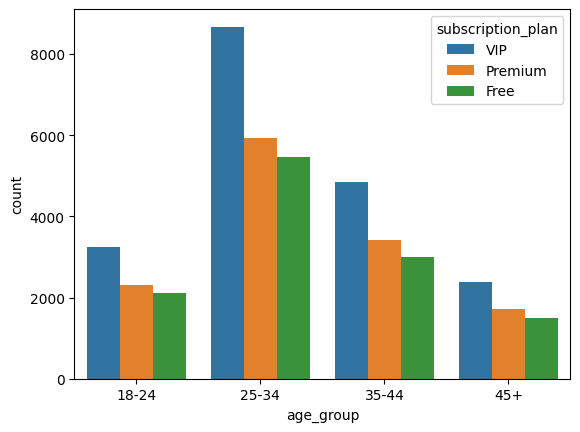

In [39]:
sns.barplot(data=age_vs_sub_plan,y='count',x='age_group',hue='subscription_plan')

In [40]:
subscribers_df.head(3)

,user_id,age_group,city_tier,subscription_date,subscription_plan,last_active_date,plan_change_date,new_subscription_plan
0,UIDJS0000751588f,18-24,Tier 1,2024-06-10,Premium,NaT,NaT,NaN
1,UIDJS000093eeb86,18-24,Tier 1,2024-11-09,Free,NaT,NaT,NaN
2,UIDJS00010d7fa1e,25-34,Tier 1,2024-08-08,Free,NaT,NaT,NaN


In [41]:
# Fetching subscribers count on daily basis
subscribtion_data=subscribers_df.groupby(['subscription_date'])['user_id'].count().to_frame().reindex()


In [42]:
subscribtion_data

,user_id
subscription_date,
2024-01-01,116
2024-01-02,137
2024-01-03,133
2024-01-04,135
2024-01-05,126
...,...
2024-11-26,145
2024-11-27,134
2024-11-28,138


In [43]:
import matplotlib.pyplot as plt

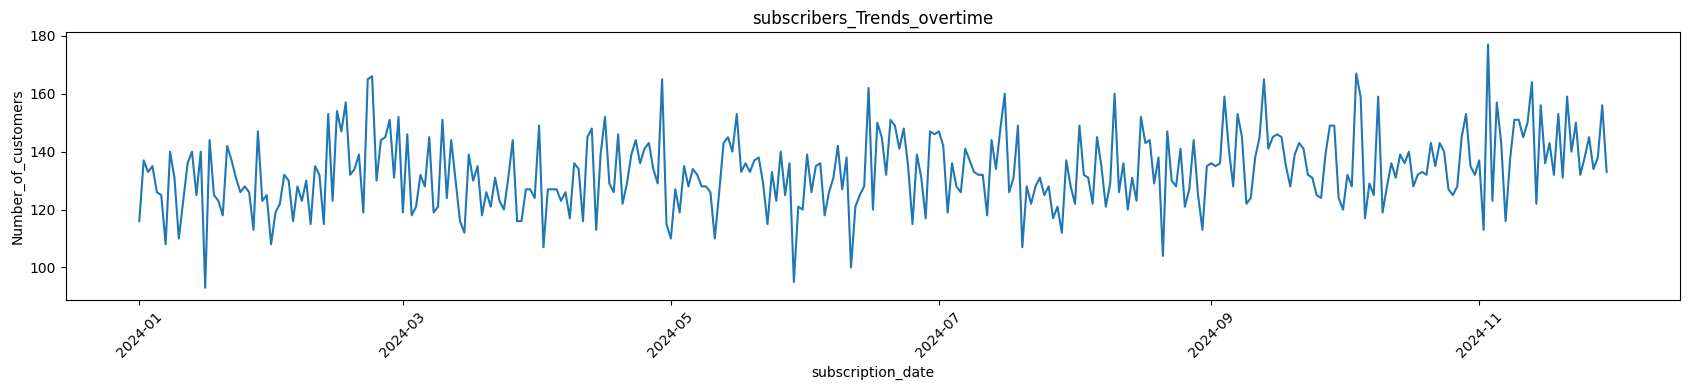

In [44]:
fig,ax=plt.subplots(figsize=(17,4))
sns.lineplot(data=subscribtion_data,x='subscription_date',y='user_id')
plt.title('subscribers_Trends_overtime')
plt.xlabel('subscription_date')
plt.ylabel('Number_of_customers')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [45]:
subscribers_df.head(3)

,user_id,age_group,city_tier,subscription_date,subscription_plan,last_active_date,plan_change_date,new_subscription_plan
0,UIDJS0000751588f,18-24,Tier 1,2024-06-10,Premium,NaT,NaT,NaN
1,UIDJS000093eeb86,18-24,Tier 1,2024-11-09,Free,NaT,NaT,NaN
2,UIDJS00010d7fa1e,25-34,Tier 1,2024-08-08,Free,NaT,NaT,NaN


In [46]:
# plan chage customers
plan_chage_customers=subscribers_df[['user_id','subscription_date','subscription_plan','plan_change_date','new_subscription_plan']].dropna()

In [47]:
plan_chage_customers['subscription_plan'].unique()

array(['Premium', 'VIP', 'Free'], dtype=object)

In [48]:
rank={'Free':1,'Premium':2,'VIP':3}
def plan_change_staus(old_plan,new_plan):
    if rank[new_plan]>rank[old_plan]:
        return 'upgrade'
    elif rank[new_plan]<rank[old_plan]:
        return 'downgrade'
    else:
        return 'no change'
plan_chage_customers['plan_change_staus']=plan_chage_customers.apply(lambda row:plan_change_staus(row['subscription_plan'],row['new_subscription_plan']),axis=1)

        

.unique is to find unique

In [49]:
plan_chage_customers['subscription_plan'].unique()

array(['Premium', 'VIP', 'Free'], dtype=object)

In [50]:
plan_chage_customers.head(3)

,user_id,subscription_date,subscription_plan,plan_change_date,new_subscription_plan,plan_change_staus
12,UIDJS000cd6a7fe8,2024-09-18,Premium,2024-12-18,VIP,upgrade
19,UIDJS0019b04b32f,2024-02-11,VIP,2024-08-11,Free,downgrade
23,UIDJS001defd7e03,2024-01-18,VIP,2024-08-18,Free,downgrade


In [51]:
subscribers_df

,user_id,age_group,city_tier,subscription_date,subscription_plan,last_active_date,plan_change_date,new_subscription_plan
0,UIDJS0000751588f,18-24,Tier 1,2024-06-10,Premium,NaT,NaT,NaN
1,UIDJS000093eeb86,18-24,Tier 1,2024-11-09,Free,NaT,NaT,NaN
2,UIDJS00010d7fa1e,25-34,Tier 1,2024-08-08,Free,NaT,NaT,NaN
3,UIDJS00013411a85,35-44,Tier 2,2024-05-31,VIP,NaT,NaT,NaN
4,UIDJS0003a3f54cf,35-44,Tier 1,2024-09-20,Premium,NaT,NaT,NaN
...,...,...,...,...,...,...,...,...
44615,UIDJSfffbb38249e,25-34,Tier 2,2024-11-12,Free,NaT,NaT,NaN
44616,UIDJSfffbd759005,45+,Tier 1,2024-05-21,VIP,NaT,NaT,NaN
44617,UIDJSfffebd3002b,25-34,Tier 1,2024-09-27,VIP,2024-10-29,NaT,NaN
44618,UIDJSffff6698084,35-44,Tier 3,2024-10-12,VIP,NaT,NaT,NaN


In [52]:
pln_chng_stat_gr=plan_chage_customers.groupby('plan_change_date')['plan_change_staus'].value_counts().to_frame().reset_index()

In [53]:
pln_chng_stat_gr.head()

,plan_change_date,plan_change_staus,count
0,2024-02-01,downgrade,7
1,2024-02-02,downgrade,7
2,2024-02-02,upgrade,3
3,2024-02-03,upgrade,6
4,2024-02-03,downgrade,5


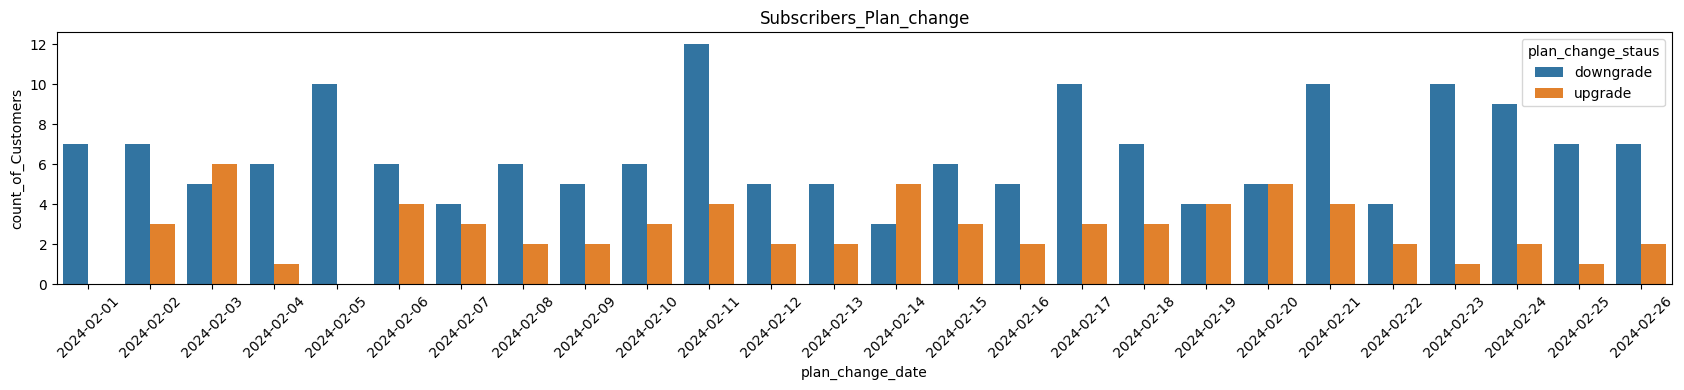

In [54]:
fig,ax=plt.subplots(figsize=(17,4))
sns.barplot(data=pln_chng_stat_gr.head(50),x='plan_change_date',y='count',hue='plan_change_staus')
plt.title('Subscribers_Plan_change')
plt.xlabel('plan_change_date')
plt.ylabel('count_of_Customers')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Instead of looking into day wise --> quarter wise or monthly wise

In [55]:
pln_chng_stat_gr['pln_ch_mth_wise']=pln_chng_stat_gr['plan_change_date'].dt.strftime("%Y,%m")

In [56]:
pln_chng_stat_gr

,plan_change_date,plan_change_staus,count,pln_ch_mth_wise
0,2024-02-01,downgrade,7,"2024,02"
1,2024-02-02,downgrade,7,"2024,02"
2,2024-02-02,upgrade,3,"2024,02"
3,2024-02-03,upgrade,6,"2024,02"
4,2024-02-03,downgrade,5,"2024,02"
...,...,...,...,...
661,2024-12-29,upgrade,4,"2024,12"
662,2024-12-30,downgrade,26,"2024,12"
663,2024-12-30,upgrade,5,"2024,12"
664,2024-12-31,downgrade,14,"2024,12"


In [57]:
pln_ch_mth_wise_df=pln_chng_stat_gr.groupby(['plan_change_staus','pln_ch_mth_wise'])['count'].sum().to_frame().reset_index()

In [58]:
pln_ch_mth_wise_df

,plan_change_staus,pln_ch_mth_wise,count
0,downgrade,"2024,02",193
1,downgrade,"2024,03",322
2,downgrade,"2024,04",380
3,downgrade,"2024,05",416
4,downgrade,"2024,06",437
5,downgrade,"2024,07",476
6,downgrade,"2024,08",556
7,downgrade,"2024,09",445
8,downgrade,"2024,10",505
9,downgrade,"2024,11",695


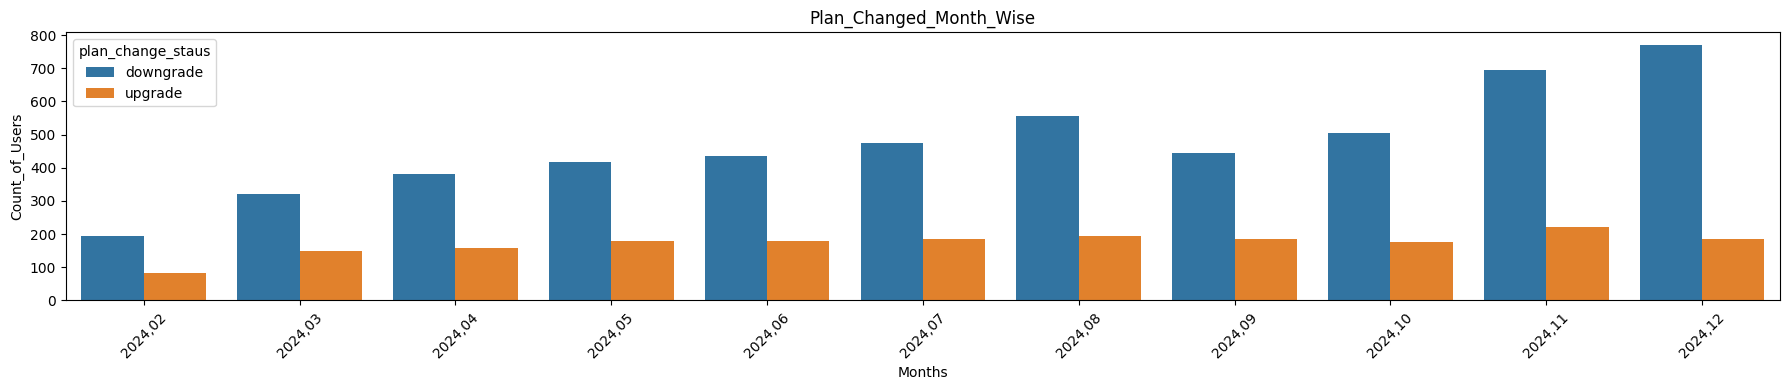

In [59]:
fig,ax=plt.subplots(figsize=(18,4))
sns.barplot(data=pln_ch_mth_wise_df,x='pln_ch_mth_wise',y='count',hue='plan_change_staus')
plt.title('Plan_Changed_Month_Wise')
plt.xlabel('Months')
plt.ylabel('Count_of_Users')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

1) Content Consumption Behavior: Patterns in total watch time, device preferences, and variations by user demographics.
2) what cause downgrade
    -Hint: combine content_consumption_df and subscribers_df

In [60]:
subscribers_df.head(3)

,user_id,age_group,city_tier,subscription_date,subscription_plan,last_active_date,plan_change_date,new_subscription_plan
0,UIDJS0000751588f,18-24,Tier 1,2024-06-10,Premium,NaT,NaT,NaN
1,UIDJS000093eeb86,18-24,Tier 1,2024-11-09,Free,NaT,NaT,NaN
2,UIDJS00010d7fa1e,25-34,Tier 1,2024-08-08,Free,NaT,NaT,NaN


In [61]:
content_con_df.head(3)

,user_id,device_type,total_watch_time_mins
0,UIDJS877cc0e02c9,Mobile,14613
1,UIDJS06384e7ff06,Mobile,13271
2,UIDJSc3997b7beb7,Mobile,4644


In [62]:
df=pd.merge(subscribers_df,content_con_df,left_on='user_id',right_on='user_id')

In [63]:
df.head()

,user_id,age_group,city_tier,subscription_date,subscription_plan,last_active_date,plan_change_date,new_subscription_plan,device_type,total_watch_time_mins
0,UIDJS0000751588f,18-24,Tier 1,2024-06-10,Premium,NaT,NaT,NaN,Mobile,20111
1,UIDJS0000751588f,18-24,Tier 1,2024-06-10,Premium,NaT,NaT,NaN,TV,11997
2,UIDJS0000751588f,18-24,Tier 1,2024-06-10,Premium,NaT,NaT,NaN,Laptop,8019
3,UIDJS000093eeb86,18-24,Tier 1,2024-11-09,Free,NaT,NaT,NaN,Mobile,2014
4,UIDJS000093eeb86,18-24,Tier 1,2024-11-09,Free,NaT,NaT,NaN,TV,969


device preferences by age_group

In [64]:
dv_age=df.groupby('age_group')['device_type'].value_counts().to_frame().reset_index()

In [65]:
dv_age

,age_group,device_type,count
0,18-24,Laptop,7676
1,18-24,Mobile,7676
2,18-24,TV,7676
3,25-34,Laptop,20069
4,25-34,Mobile,20069
5,25-34,TV,20069
6,35-44,Laptop,11274
7,35-44,Mobile,11274
8,35-44,TV,11274
9,45+,Laptop,5601


<Axes: xlabel='count', ylabel='age_group'>

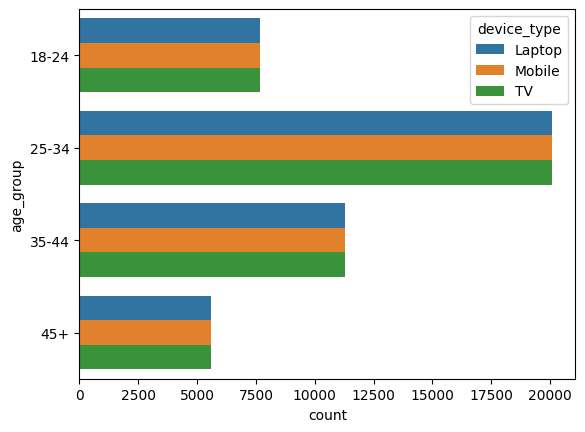

In [66]:
sns.barplot(data=dv_age,x='count',y='age_group',hue='device_type')

Inactivity Analysis: Patterns of inactivity across age groups, city tiers, and subscription plans.

In [67]:
subscribers_df.head()

,user_id,age_group,city_tier,subscription_date,subscription_plan,last_active_date,plan_change_date,new_subscription_plan
0,UIDJS0000751588f,18-24,Tier 1,2024-06-10,Premium,NaT,NaT,NaN
1,UIDJS000093eeb86,18-24,Tier 1,2024-11-09,Free,NaT,NaT,NaN
2,UIDJS00010d7fa1e,25-34,Tier 1,2024-08-08,Free,NaT,NaT,NaN
3,UIDJS00013411a85,35-44,Tier 2,2024-05-31,VIP,NaT,NaT,NaN
4,UIDJS0003a3f54cf,35-44,Tier 1,2024-09-20,Premium,NaT,NaT,NaN


In [68]:
subscribers_df['costomer_activity']=subscribers_df['last_active_date'].fillna("inactive")

In [69]:
subscribers_df.head()

,user_id,age_group,city_tier,subscription_date,subscription_plan,last_active_date,plan_change_date,new_subscription_plan,costomer_activity
0,UIDJS0000751588f,18-24,Tier 1,2024-06-10,Premium,NaT,NaT,NaN,inactive
1,UIDJS000093eeb86,18-24,Tier 1,2024-11-09,Free,NaT,NaT,NaN,inactive
2,UIDJS00010d7fa1e,25-34,Tier 1,2024-08-08,Free,NaT,NaT,NaN,inactive
3,UIDJS00013411a85,35-44,Tier 2,2024-05-31,VIP,NaT,NaT,NaN,inactive
4,UIDJS0003a3f54cf,35-44,Tier 1,2024-09-20,Premium,NaT,NaT,NaN,inactive


In [70]:
# subscribers_df['last_active_date'].value_counts()
subscribers_df['last_active_date'].max()

Timestamp('2024-12-29 00:00:00')

In [71]:
threshold_date = subscribers_df['last_active_date'].max() - pd.Timedelta(days=60)
threshold_date

Timestamp('2024-10-30 00:00:00')

In [72]:
subscribers_df['is_inactive']=subscribers_df['last_active_date'].isna()|(subscribers_df['last_active_date']<threshold_date)

In [73]:
subscribers_df.head()

,user_id,age_group,city_tier,subscription_date,subscription_plan,last_active_date,plan_change_date,new_subscription_plan,costomer_activity,is_inactive
0,UIDJS0000751588f,18-24,Tier 1,2024-06-10,Premium,NaT,NaT,NaN,inactive,True
1,UIDJS000093eeb86,18-24,Tier 1,2024-11-09,Free,NaT,NaT,NaN,inactive,True
2,UIDJS00010d7fa1e,25-34,Tier 1,2024-08-08,Free,NaT,NaT,NaN,inactive,True
3,UIDJS00013411a85,35-44,Tier 2,2024-05-31,VIP,NaT,NaT,NaN,inactive,True
4,UIDJS0003a3f54cf,35-44,Tier 1,2024-09-20,Premium,NaT,NaT,NaN,inactive,True


In [74]:
subscribers_df[subscribers_df['is_inactive']][['age_group','is_inactive']].value_counts()

age_group  is_inactive
25-34      True           18928
35-44      True           10707
18-24      True            7208
45+        True            5313
Name: count, dtype: int64

subscriber inactivity by age_group ,isinactive

<Axes: ylabel='age_group,is_inactive'>

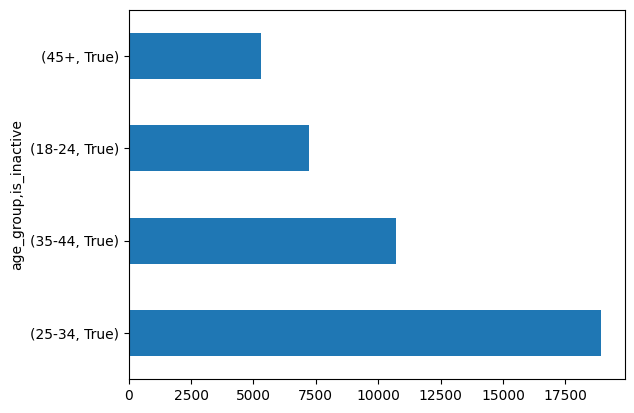

In [79]:
subscribers_df[subscribers_df['is_inactive']==True][['age_group','is_inactive']].value_counts().plot(kind='barh')

<Axes: ylabel='age_group,city_tier'>

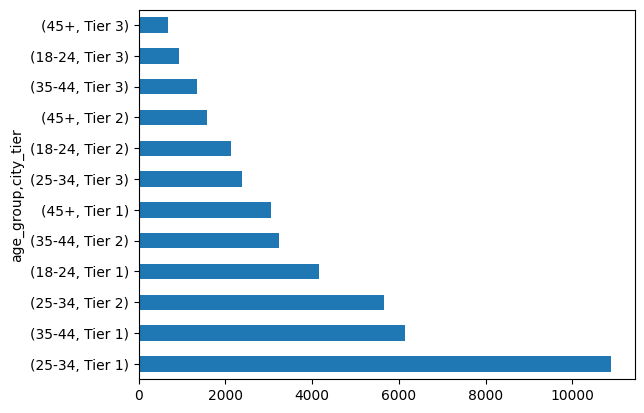

In [80]:
subscribers_df[subscribers_df['is_inactive']==True][['age_group','city_tier']].value_counts().plot(kind='barh')

<Axes: xlabel='age_group', ylabel='count'>

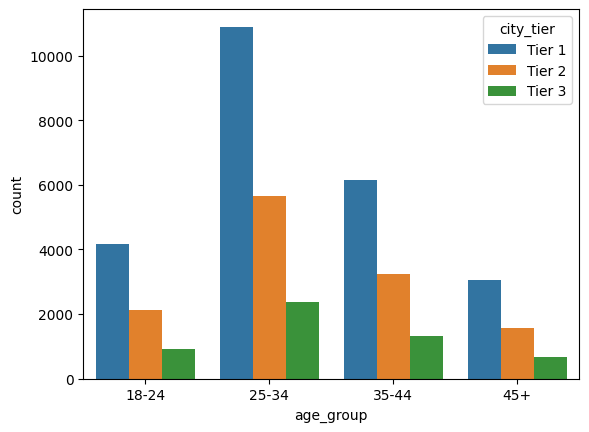

In [82]:
sns.countplot(data=subscribers_df[subscribers_df['is_inactive']==True],x='age_group',hue='city_tier')

<Axes: ylabel='is_inactive,subscription_plan'>

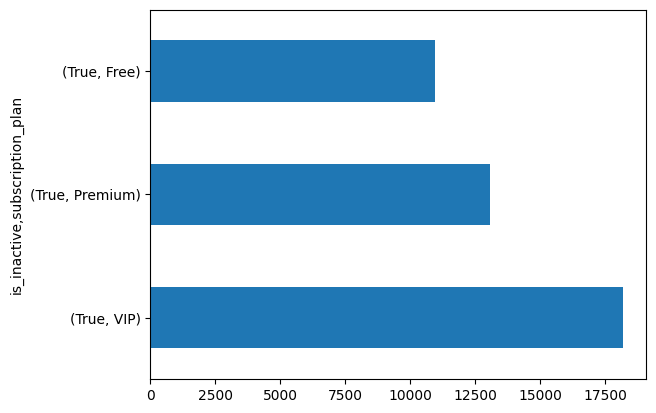

In [81]:
subscribers_df[subscribers_df['is_inactive']==True][['is_inactive','subscription_plan']].value_counts().plot(kind='barh')